<a href="https://colab.research.google.com/github/vikramsingh456/ai-ml/blob/dev/Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import pandas as pd

data = {
    'House_Size': [800, 1000, 1200, 1400, 1600,
                   1800, 2000, 2200, 2400, 2600],

    'House_Price': [40, 50, 58, 68, 75,
                    85, 92, 105, 115, 125]
}

df = pd.DataFrame(data)

X = df[['House_Size']]  # DataFrame, 2D
#print(X)
y = df['House_Price'] # Series, 1D
#print(y)
print(df)



   House_Size
0         800
1        1000
2        1200
3        1400
4        1600
5        1800
6        2000
7        2200
8        2400
9        2600
   House_Size  House_Price
0         800           40
1        1000           50
2        1200           58
3        1400           68
4        1600           75
5        1800           85
6        2000           92
7        2200          105
8        2400          115
9        2600          125


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2, # 80% → Training , 20% → Testing
    random_state=42
)

#print(X_train)
#print(X_test)

#model = LinearRegression()
#model.fit(X_train, y_train)




In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
#print(y_pred)
result = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

print(result)
print(model.coef_)
print(model.intercept_)


#New House
print("New House Price")
newPrice = pd.DataFrame({
    'House_Size': [1700]
})
print(model.predict(newPrice))

#Checking what if pass y then x  value?




   Actual   Predicted
8     115  113.646552
1      50   48.353448
[0.04663793]
1.7155172413793025
New House Price
[81.]


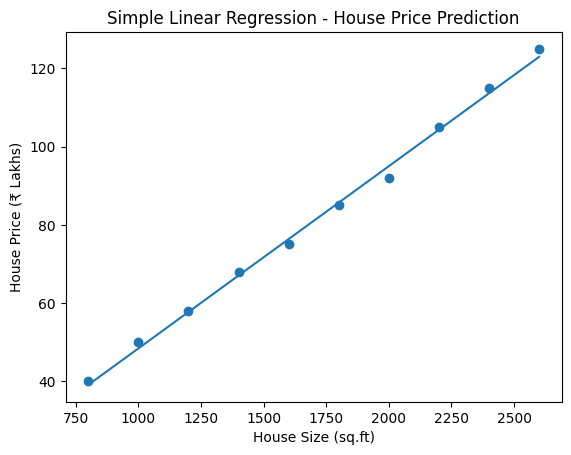

In [ ]:

import pandas as pd
import matplotlib.pyplot as plt

plt.scatter(df['House_Size'], df['House_Price'])

plt.plot(
    df['House_Size'], # X
    model.predict(df[['House_Size']]) # y
)

plt.xlabel('House Size (sq.ft)')
plt.ylabel('House Price (₹ Lakhs)')
plt.title('Simple Linear Regression - House Price Prediction')

plt.show()


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression


# Step 1: Create dataset
data = {
    'House_Size': [800, 1000, 1200, 1400, 1600,
                   1800, 2000, 2200, 2400, 2600],

    'Bedrooms': [1, 2, 2, 2, 3,
                 3, 3, 4, 4, 4],

    'Age': [15, 12, 10, 8, 7,
            5, 4, 3, 2, 1],

    'Distance': [18, 15, 13, 11, 10,
                 8, 7, 5, 4, 3],

    'House_Price': [35, 45, 55, 65, 78,
                    90, 102, 118, 132, 145]
}

df = pd.DataFrame(data)

# print(df)



# Step 2: Define X and y

X = df[['House_Size', 'Bedrooms', 'Age', 'Distance']] # 4 input features

y = df['House_Price']



# Step 3: Split training and testing data

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X Train:")
print(X_train)

print("\nX Test:")
print(X_test)

# Create the Multiple Linear Regression model
# Step 4: Create model

model = LinearRegression()



# Step 5: Train model

model.fit(X_train, y_train)

print("X columns")
print(X.columns)

coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

print("Coefficients....")

print(coefficients)


# Step 6: Predict test data

y_pred = model.predict(X_test)


# Step 7: Compare Actual vs Predicted

results = X_test.copy()

results['Actual_Price'] = y_test
results['Predicted_Price'] = y_pred

print(results)

print("Intercept:", model.intercept_)

for feature, coefficient in zip(X.columns, model.coef_):
    print(feature, ":", coefficient)


# Step 8: Predict a new house

new_house = pd.DataFrame({
    'House_Size': [1700],
    'Bedrooms': [3],
    'Age': [6],
    'Distance': [9]
})

predicted_price = model.predict(new_house)


print(
    "\nPredicted Price:",
    round(predicted_price[0], 2),
    "Lakhs"
)

"""

8 houses → Training
2 houses → Testing


X = Inputs / Features
---------------------
House_Size
Bedrooms
Age
Distance


y = Output / Target
-------------------
House_Price


House Size ─────┐
Bedrooms ───────┤
Age ────────────┼──→ Model ──→ House Price
Distance ───────┘


| Regression      | X                                | y           |
| --------------- | -------------------------------- | ----------- |
| Simple Linear   | House Size                       | House Price |
| Multiple Linear | Size + Bedrooms + Age + Distance | House Price |

model.coef_ and model.intercept_


       Feature       Coefficient
0   House_Size          0.05
1     Bedrooms          2.50
2          Age         -0.30
3     Distance         -0.80


Coefficient = How much the predicted house price changes when that feature increases by 1,
while the other features stay the same.


House Size coefficient = +0.05
If house size increases by 1 sq.ft,
predicted price increases by approximately ₹0.05 lakh, assuming everything else remains the same.

100 × 0.05 = 5 lakhs

+100 sq.ft → +₹5 lakh

Size ↑ → Price ↑


Bedrooms coefficient = +2.50
Adding one bedroom is associated with approximately ₹2.5 lakh higher predicted price,
assuming size, age and distance stay the same.

2 bedrooms → 3 bedrooms

Price change ≈ +₹2.5 lakh

Bedrooms ↑ → Price ↑



Age coefficient = -0.30

Here we have a negative coefficient.


If the house becomes 1 year older,
predicted price decreases by approximately ₹0.30 lakh, keeping everything else the same.

5 years old → 6 years old

Price change ≈ -₹0.30 lakh

Age ↑ → Price ↓



Distance coefficient = -0.80
For every additional 1 km away from the city center,
predicted price decreases by approximately ₹0.8 lakh, assuming everything else stays the same.

5 km → 10 km

Difference = 5 km

5 × -0.8 = -4 lakh

Moving 5 km farther away → predicted price approximately ₹4 lakh lower.


Positive coefficient (+)
        ↓
Feature increases
        ↓
Prediction increases


Negative coefficient (-)
        ↓
Feature increases
        ↓
Prediction decreases



| Feature    | Example Coefficient | Meaning                 |
| ---------- | ------------------: | ----------------------- |
| House Size |               +0.05 | Larger → Price ↑        |
| Bedrooms   |               +2.50 | More bedrooms → Price ↑ |
| Age        |               -0.30 | Older → Price ↓         |
| Distance   |               -0.80 | Farther away → Price ↓  |


print(model.intercept_)

The intercept is the model's starting/base value mathematically, when all input features are zero.

Predicted Price = Intercept + contributions from all features

Price =
10
+ (0.05 × House Size)
+ (2.5 × Bedrooms)
- (0.3 × Age)
- (0.8 × Distance)



House Size = 1700
Bedrooms   = 3
Age        = 6
Distance   = 9

Price =
10
+ (0.05 × 1700)
+ (2.5 × 3)
- (0.3 × 6)
- (0.8 × 9)


Intercept              = +10

House Size
0.05 × 1700            = +85

Bedrooms
2.5 × 3                = +7.5

Age
-0.3 × 6               = -1.8

Distance
-0.8 × 9               = -7.2
                         -----
Predicted Price         = 93.5 Lakhs


print("Intercept:", model.intercept_)

for feature, coefficient in zip(X.columns, model.coef_):
    print(feature, ":", coefficient)


Coefficient = effect of each feature on the prediction
Positive coefficient = prediction tends to increase
Negative coefficient = prediction tends to decrease
Intercept = mathematical baseline
model.predict() = combines all these values to produce the final prediction

"""

X Train:
   House_Size  Bedrooms  Age  Distance
5        1800         3    5         8
0         800         1   15        18
7        2200         4    3         5
2        1200         2   10        13
9        2600         4    1         3
4        1600         3    7        10
3        1400         2    8        11
6        2000         3    4         7

X Test:
   House_Size  Bedrooms  Age  Distance
8        2400         4    2         4
1        1000         2   12        15
X columns
Index(['House_Size', 'Bedrooms', 'Age', 'Distance'], dtype='object')
Coefficients....
      Feature  Coefficient
0  House_Size     0.077198
1    Bedrooms    -0.265700
2         Age     5.157005
3    Distance    -2.910628
   House_Size  Bedrooms  Age  Distance  Actual_Price  Predicted_Price
8        2400         4    2         4           132       131.500000
1        1000         2   12        15            45        43.507246
Intercept: -51.3840579710145
House_Size : 0.0771980676328502
Bedrooms : -

'\n\n8 houses → Training\n2 houses → Testing\n\n\nX = Inputs / Features\n---------------------\nHouse_Size\nBedrooms\nAge\nDistance\n\n\ny = Output / Target\n-------------------\nHouse_Price\n\n\nHouse Size ─────┐\nBedrooms ───────┤\nAge ────────────┼──→ Model ──→ House Price\nDistance ───────┘\n\n\n| Regression      | X                                | y           |\n| --------------- | -------------------------------- | ----------- |\n| Simple Linear   | House Size                       | House Price |\n| Multiple Linear | Size + Bedrooms + Age + Distance | House Price |\n\nmodel.coef_ and model.intercept_\n\n\n       Feature       Coefficient\n0   House_Size          0.05\n1     Bedrooms          2.50\n2          Age         -0.30\n3     Distance         -0.80\n\n\nCoefficient = How much the predicted house price changes when that feature increases by 1,\nwhile the other features stay the same.\n\n\nHouse Size coefficient = +0.05\nIf house size increases by 1 sq.ft,\npredicted price

In [ ]:
data = {
    'House_Size': [800, 1000, 1200, 1400, 1600,
                   1800, 2000, 2200, 2400, 2600],

    'Bedrooms': [1, 2, 2, 2, 3,
                 3, 3, 4, 4, 4],

    'Age': [15, 12, 10, 8, 7,
            5, 4, 3, 2, 1],

    'Distance': [18, 15, 13, 11, 10,
                 8, 7, 5, 4, 3],

    'House_Price': [35, 45, 55, 65, 78,
                    90, 102, 118, 132, 145]
}

data = {
    'House_Size': [800, 1000, 1200, 1400, 1600,
                   1800, 2000, 2200, 2400, 2600],

    'Bedrooms': [1, 2, 2, 2, 3,
                 3, 3, 4, 4, 4],

    'Age': [15, 12, 10, 8, 7,
            5, 4, 3, 2, 1],

    'Distance': [18, 15, 13, 11, 10,
                 8, 7, 5, 4, 3],

    'House_Price': [35, 45, 55, 65, 78,
                    90, 102, 118, 132, 145]
}

df = pd.DataFrame(data)

# print(df)



# Step 2: Define X and y

X = df[['House_Size', 'Bedrooms', 'Age', 'Distance']] # 4 input features

y = df['House_Price']



# Step 3: Split training and testing data

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


model = LinearRegression()
model.fit(X_train, y_train)


new_house = pd.DataFrame({
    'House_Size': [1700],
    'Bedrooms': [400],
    'Age': [6],
    'Distance': [9]
})

predicted_price = model.predict(new_house)


print(
    "\nPredicted Price:",
    round(predicted_price[0], 2),
    "Lakhs"
)

model.fit(X_train, y_train)


Predicted Price: -21.68 Lakhs


LinearRegression()

   Speed  Actual  Predicted
0     20       9   9.214286
1     40       7   6.471429
2     60       5   5.371429
3     80       6   5.914286
4    100       8   8.100000
5    120      12  11.928571

 Predicted Fule Consumption: 20.75


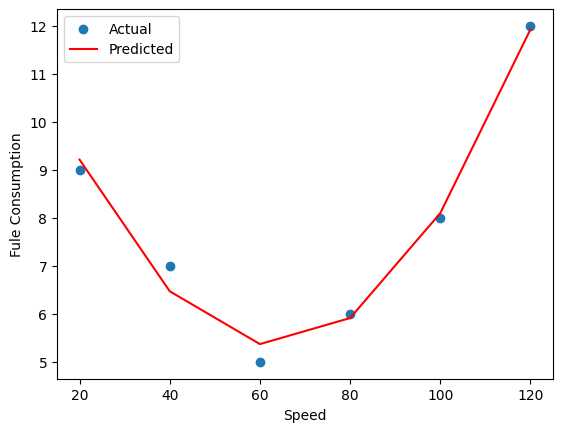

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

import pandas as pd
import matplotlib.pyplot as plt

data = {
    'Speed':[20,40, 60,80, 100,120],
    'Fule_Consumption' :[9,7,5,6,8,12]
}

df = pd.DataFrame(data)

X = df[['Speed']]
y = df['Fule_Consumption']

poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

model = LinearRegression()
model.fit(X_poly, y)

y_pred = model.predict(X_poly)

results = pd.DataFrame({'Speed':df['Speed'],'Actual': y, 'Predicted': y_pred})
print(results)

new_speed = pd.DataFrame({'Speed': [150]})
new_speed_poly = poly.transform(new_speed)

prediection = model.predict(new_speed_poly)

print("\n Predicted Fule Consumption:", round(prediection[0],2))

plt.scatter(df['Speed'], df['Fule_Consumption'], label='Actual')
plt.plot(df['Speed'], y_pred, color='red', label='Predicted')
plt.xlabel('Speed')
plt.ylabel('Fule Consumption')
plt.legend()
plt.show()






